In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    TimeSeriesSplit,
)

In [5]:
NEW_PRICE_FEATURES = [
    "price_to_sma200", "stddev_252", "max_drawdown_252", "atr_pct",  # Kept from before
    "return_3m", "return_12m", "distance_from_52wk_high"             # New macro momentum
]

NEW_FUND_FEATURES = [
    "roe", "roa", "debt_equity", "current_ratio", "cash_to_assets", "fcf_to_assets", # Static
    "roe_chg_qoq", "roa_chg_qoq", "fcf_to_assets_chg_qoq", "debt_equity_chg_qoq"     # Velocity
]
MKT      = ["vix","vix_pctile_252"]

In [6]:
# XGBoost Model
df = pd.read_parquet('train_dataset_quarterly.parquet')
tscv = TimeSeriesSplit(n_splits=5)

NEW_PRICE_FEATURES = [
    "price_to_sma200", "stddev_252", "max_drawdown_252", "atr_pct",  # Kept from before
    "return_3m", "return_12m", "distance_from_52wk_high"             # New macro momentum
]

NEW_FUND_FEATURES = [
    "roe", "roa", "debt_equity", "current_ratio", "cash_to_assets", "fcf_to_assets", # Static
    "roa_chg_qoq", "fcf_to_assets_chg_qoq", "debt_equity_chg_qoq"     # Velocity
]
MKT      = ["vix","vix_pctile_252"]

ALL_FEATURES = NEW_PRICE_FEATURES + NEW_FUND_FEATURES + MKT

# Sector is categorical — XGBoost handles it natively via enable_categorical
CATEGORICAL_FEATURES = ["sector"]
FEATURES = ALL_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_TICKERS = {"NBIS", "BRK.B", "AMBP", "CRM", "BE", "FI", "K", "DFS"}
TICKERS = sorted(set(df["ticker"].unique()) - EXCLUDED_TICKERS)

model_df = df[df["ticker"].isin(TICKERS)].dropna(subset=FEATURES + ["target_return"]).copy()
for c in CATEGORICAL_FEATURES:
    model_df[c] = model_df[c].astype("category")
X = model_df[FEATURES]
y = model_df["target_return"]
dates = model_df["date"]

train_mask = dates < "2022-01-01"
test_mask = dates >= "2022-01-01"

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# --- XGBoost ---

xgb_model = xgb.XGBRegressor(
    objective='reg:pseudohubererror',
    n_estimators=100,        # back to conservative
    max_depth=2,             # back to conservative
    learning_rate=0.05,      # back to conservative
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
ic_xgb = spearmanr(y_test, y_pred_xgb).statistic
print("XGBoost Rank IC:", ic_xgb)

# --- Feature importance (useful diagnostic — which features are actually driving predictions) ---
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)


XGBoost Rank IC: 0.019281571832533786
vix                        0.112666
atr_pct                    0.106093
vix_pctile_252             0.078038
return_3m                  0.075550
roe                        0.060171
debt_equity_chg_qoq        0.056838
return_12m                 0.056261
max_drawdown_252           0.055123
debt_equity                0.054436
distance_from_52wk_high    0.048402
fcf_to_assets_chg_qoq      0.047878
roa                        0.047742
price_to_sma200            0.039803
roa_chg_qoq                0.034290
sector                     0.033518
stddev_252                 0.032412
cash_to_assets             0.030774
current_ratio              0.030003
fcf_to_assets              0.000000
dtype: float32


In [7]:
# Build a results dataframe with everything you need aligned together
results_df = pd.DataFrame({
    "date": dates[test_mask].reset_index(drop=True),
    "ticker": model_df.loc[y_test.index, "ticker"].reset_index(drop=True),
    "y_test": pd.Series(y_test).reset_index(drop=True),
    "y_pred": pd.Series(y_pred_xgb).reset_index(drop=True),
})

def bucket_by_period_with_edges(df, value_col, date_col="date",
                                  labels=("Strong Sell", "Sell", "Hold", "Buy", "Strong Buy")):
    """Same as before, but also returns the actual bin edges used per period."""
    buckets = pd.Series(index=df.index, dtype="object")
    edges_by_period = {}
    
    for period, group in df.groupby(date_col):
        binned, bins = pd.qcut(group[value_col], q=len(labels), labels=labels,
                                 duplicates="drop", retbins=True)
        buckets.loc[group.index] = binned
        edges_by_period[period] = bins
    
    return pd.Categorical(buckets, categories=labels, ordered=True), edges_by_period

results_df["actual_bucket"], actual_edges = bucket_by_period_with_edges(results_df, "y_test")
results_df["pred_bucket"], pred_edges = bucket_by_period_with_edges(results_df, "y_pred")

# Print the edges per quarter for the ACTUAL returns (most useful to inspect)
for period, bins in actual_edges.items():
    bins_pct = [f"{b:.1%}" for b in bins]
    print(f"{period}: {bins_pct}")

# Overall accuracy — exact bucket match
acc = accuracy_score(results_df["actual_bucket"], results_df["pred_bucket"])
print(f"Bucket classification accuracy: {acc:.2%}")

# Confusion matrix
labels_order = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
cm = confusion_matrix(results_df["actual_bucket"], results_df["pred_bucket"], labels=labels_order)
cm_df = pd.DataFrame(cm, index=[f"Actual: {l}" for l in labels_order],
                          columns=[f"Pred: {l}" for l in labels_order])
print(cm_df)

# Per-bucket precision/recall
print(classification_report(results_df["actual_bucket"], results_df["pred_bucket"],
                             labels=labels_order, zero_division=0))

# Directional accuracy — unchanged, still useful as-is
directional_acc = (np.sign(results_df["y_test"]) == np.sign(results_df["y_pred"])).mean()
print(f"Directional accuracy (up/down only): {directional_acc:.2%}")

# Bonus: "within one bucket" accuracy — more forgiving, often more informative
bucket_num_actual = results_df["actual_bucket"].cat.codes
bucket_num_pred = results_df["pred_bucket"].cat.codes
within_one = (abs(bucket_num_actual - bucket_num_pred) <= 1).mean()
print(f"Within-one-bucket accuracy: {within_one:.2%}")

2022-01-01 00:00:00: ['-63.5%', '-24.9%', '-17.9%', '-10.2%', '-2.3%', '16.0%']
2022-04-01 00:00:00: ['-43.4%', '-12.0%', '-7.4%', '-0.7%', '4.6%', '29.5%']
2022-07-01 00:00:00: ['-46.0%', '-2.7%', '6.5%', '14.6%', '20.9%', '81.2%']
2022-10-01 00:00:00: ['-22.9%', '-3.6%', '2.6%', '9.7%', '19.3%', '76.1%']
2023-01-01 00:00:00: ['-22.1%', '-5.1%', '1.8%', '7.7%', '15.7%', '85.5%']
2023-04-01 00:00:00: ['-27.4%', '-11.3%', '-6.2%', '-0.6%', '6.4%', '55.3%']
2023-07-01 00:00:00: ['-15.0%', '1.6%', '8.8%', '14.7%', '22.6%', '52.5%']
2023-10-01 00:00:00: ['-24.3%', '-0.4%', '5.8%', '11.0%', '19.8%', '73.7%']
2024-01-01 00:00:00: ['-27.7%', '-10.2%', '-5.4%', '2.7%', '10.0%', '22.8%']
2024-04-01 00:00:00: ['-43.7%', '-4.1%', '3.3%', '9.9%', '15.8%', '56.9%']
2024-07-01 00:00:00: ['-37.8%', '-14.1%', '-8.0%', '-0.2%', '9.6%', '103.3%']
2024-10-01 00:00:00: ['-35.5%', '-13.3%', '-5.3%', '2.0%', '10.9%', '50.9%']
2025-01-01 00:00:00: ['-40.4%', '-8.1%', '0.9%', '8.0%', '26.0%', '73.8%']
2025-04

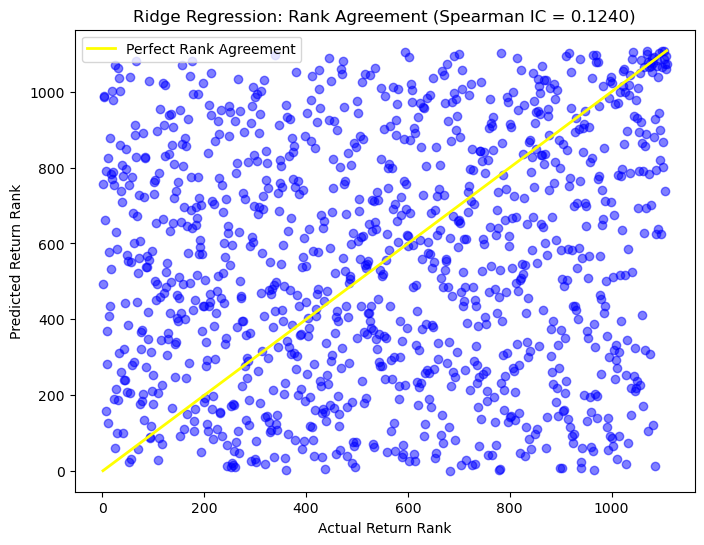

In [53]:
# Plot
# Note: normalize to arrays first — pd.Series(y_test) keeps a non-default index,
# which misaligns against the numpy prediction array (ValueError otherwise).
ic_pooled = spearmanr(y_test, y_pred_xgb).statistic
rank_actual = pd.Series(np.asarray(y_test)).rank().values
rank_pred = pd.Series(np.asarray(y_pred_xgb)).rank().values

plt.figure(figsize=(8, 6))
plt.scatter(rank_actual, rank_pred, color='blue', alpha=0.5)
plt.plot([rank_actual.min(), rank_actual.max()],
         [rank_actual.min(), rank_actual.max()],
         color='yellow', linewidth=2, label='Perfect Rank Agreement')
plt.xlabel("Actual Return Rank")
plt.ylabel("Predicted Return Rank")
plt.title(f"Ridge Regression: Rank Agreement (Spearman IC = {ic_pooled:.4f})")
plt.legend()
plt.show()